In [1]:
import numpy as np
import pandas as pd
import cvxpy as cvx
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
ASSETS=['Main Battle Force', 'C-C5ISRT', 'One-way attack USVs',
        'UUVs', 'Counter Drone Interceptors']
SCENARIOS=['Presence/Competition', 'Peer Conflict: A2/AD', 'Peer Conflict: AD',
           'Asymmetric/Guerilla Warfare', 'Regional Contingency, Non peer', 'Blockade/Embargo']
V=np.array([
    [2.5, 0.6, 0.2, 0.4, 0.3],
    [2.1, 1.4, 2.3, 1.2, 1.8],
    [1.8, 2.2, 2.2, 1.2, 1.8],
    [0.5, 1.2, 1.5, 1.5, 1.8],
    [0.8, 0.9, 0.5, 0.4, 0.8],
    [1.4, 1.0, 2.1, 1.1, 0.7],
])
n=len(ASSETS)

p=np.array([0.35, 0.15, 0.05, 0.20, 0.15, 0.10])
pd.DataFrame(V, index=SCENARIOS, columns=ASSETS).assign(**{"P(scenario)": p})

,Main Battle Force,C-C5ISRT,One-way attack USVs,UUVs,Counter Drone Interceptors,P(scenario)
Presence/Competition,2.5,0.6,0.2,0.4,0.3,0.35
Peer Conflict: A2/AD,2.1,1.4,2.3,1.2,1.8,0.15
Peer Conflict: AD,1.8,2.2,2.2,1.2,1.8,0.05
Asymmetric/Guerilla Warfare,0.5,1.2,1.5,1.5,1.8,0.20
"Regional Contingency, Non peer",0.8,0.9,0.5,0.4,0.8,0.15
Blockade/Embargo,1.4,1.0,2.1,1.1,0.7,0.10


In [3]:
r=p@V
sigma=np.empty((n, n))
for i in range(n):
    for j in range(n):
        sigma[i,j]=sum(p[c]*(V[c,i]-r[i])*(V[c,j]-r[j]) for c in range(len(p)))

summary = pd.DataFrame({'Expected Return (mu)': r}, index=ASSETS)
display(summary.round(4))


,Expected Return (mu)
Main Battle Force,1.640
C-C5ISRT,1.005
One-way attack USVs,1.110
UUVs,0.850
Counter Drone Interceptors,1.015


In [4]:
x = cvx.Variable(r.size, nonneg=True)
return_rate = cvx.Parameter()
obj = cvx.Minimize(cvx.quad_form(x, sigma))
cons = [r.T @ x >= return_rate, cvx.sum(x) == 1.]
prob = cvx.Problem(obj, cons)

rates = np.linspace(r.min(), r.max(), 1000)
assets = np.empty((rates.size, n))
variances = np.empty(rates.size)
for i, rate in enumerate(rates):
    return_rate.value = rate
    prob.solve(solver='CLARABEL', verbose=False)
    if prob.status == 'optimal':
        assets[i, :] = x.value
        variances[i] = prob.value
    else:
        assets[i, :] = np.nan
        variances[i] = np.nan


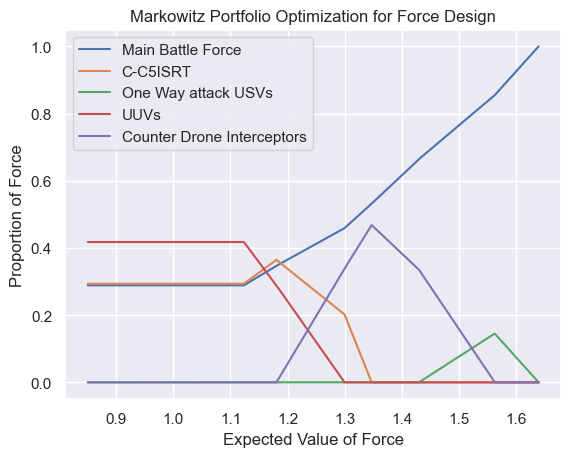

In [5]:
plt.plot(rates, assets[:,0], label='Main Battle Force')
plt.plot(rates, assets[:,1], label='C-C5ISRT')
plt.plot(rates, assets[:,2], label='One Way attack USVs')
plt.plot(rates, assets[:,3], label='UUVs')
plt.plot(rates, assets[:,4], label='Counter Drone Interceptors')

plt.xlabel("Expected Value of Force")
plt.ylabel("Proportion of Force")
plt.legend()
plt.title("Markowitz Portfolio Optimization for Force Design")
plt.savefig("OptimalForceDesignByExpectedValue.pdf", bbox_inches='tight', pad_inches=0)

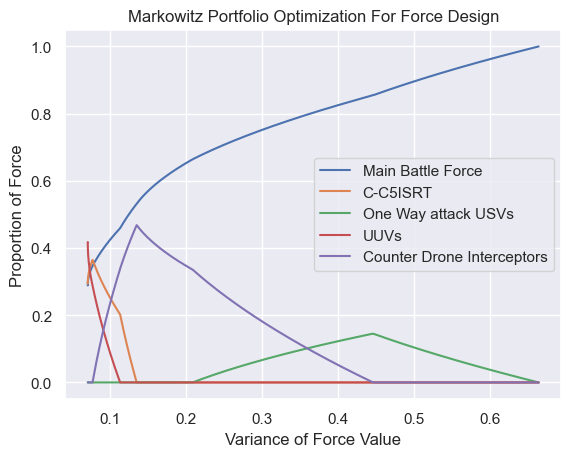

In [6]:
plt.plot(variances, assets[:,0], label='Main Battle Force')
plt.plot(variances, assets[:,1], label='C-C5ISRT')
plt.plot(variances, assets[:,2], label='One Way attack USVs')
plt.plot(variances, assets[:,3], label='UUVs')
plt.plot(variances, assets[:,4], label='Counter Drone Interceptors')

plt.xlabel("Variance of Force Value")
plt.ylabel("Proportion of Force")
plt.legend()
plt.title("Markowitz Portfolio Optimization For Force Design")
plt.savefig("OptimalForceDesignByVariance.pdf", bbox_inches='tight', pad_inches=0)